# Week 6 — Quantum Kernels and Capstone

**Quantum Artificial Intelligence**

---

The variational classifier of Week 5 trains a quantum circuit like a neural network — powerful, but
prone to barren plateaus and finicky optimization. This final week develops a complementary and often
more robust approach: **quantum kernel methods**. Instead of training the quantum circuit, we use it
only to *embed* data into a high-dimensional Hilbert space and measure similarities, then hand those
similarities to a classical support-vector machine. The quantum computer computes a **kernel**; the
classical optimizer is convex and reliable.

We derive the quantum kernel, implement it from scratch and in PennyLane, train a quantum-kernel SVM,
and finish with a **capstone** that puts quantum and classical models side by side on the same task —
an honest look at where quantum machine learning stands.

Roadmap:

1. **Kernel methods**, briefly: the kernel trick and why embeddings matter.
2. **The quantum kernel**: fidelity between data-encoded states.
3. A **quantum-kernel SVM** trained and evaluated.
4. **Capstone**: quantum vs classical on a shared benchmark, and course conclusions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)


## 1. Kernel methods and the kernel trick

A linear classifier cannot separate data that is not linearly separable — unless we first map it into
a higher-dimensional **feature space** where it becomes separable. A **kernel** $k(x, x')$ computes the
inner product of two data points *in that feature space* without ever forming the (possibly infinite-
dimensional) feature vectors explicitly:

$$
k(x, x') = \langle \phi(x),\, \phi(x') \rangle .
$$

This is the **kernel trick**. Support vector machines need only the matrix of pairwise kernels, the
**Gram matrix** $K_{ij}=k(x_i,x_j)$, to find a maximum-margin separating boundary — and that
optimization is **convex**, so it has no local minima and no barren plateaus.

The quantum idea (Havlíček et al., 2019; Schuld & Killoran, 2019) is to let the feature map $\phi$ be a
**quantum state**: $\phi(x) = |\phi(x)\rangle$, the data encoded into qubits. If that quantum feature
space is hard to simulate classically, the resulting kernel may capture structure no efficient
classical kernel can — a concrete route to quantum advantage in machine learning.


## 2. The quantum kernel

Encode each data point with a feature-map circuit $U(x)$, giving $|\phi(x)\rangle = U(x)|0\rangle$. The
natural similarity between two encoded states is their **fidelity** — the squared overlap:

$$
k(x, x') = \big|\langle \phi(x') | \phi(x)\rangle\big|^2
= \big|\langle 0|\, U^\dagger(x')\,U(x)\,|0\rangle\big|^2 .
$$

This has a beautiful circuit realization: apply $U(x)$ then $U^\dagger(x')$ to $|0\rangle$ and measure
the probability of returning to $|0\dots0\rangle$ — the **overlap test**. If $x=x'$ the states are
identical and $k=1$; as the encoded states diverge, $k$ falls toward $0$. We implement the kernel both
from scratch (state vectors) and in PennyLane, and confirm they agree.


In [2]:
# --- From-scratch quantum kernel via state vectors ---
from functools import reduce
ket0 = np.array([1,0], dtype=complex)
def kron_all(ms): return reduce(np.kron, ms)
def Ry(t): return np.array([[np.cos(t/2), -np.sin(t/2)],[np.sin(t/2), np.cos(t/2)]], dtype=complex)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
I2 = np.eye(2, dtype=complex)
def op_on(n, g, t): return kron_all([g if w==t else I2 for w in range(n)])

def feature_state(x):
    # Encode a 2-D point into 2 qubits with an entangling feature map.
    s = kron_all([ket0, ket0])
    s = op_on(2, Ry(x[0]), 0) @ s
    s = op_on(2, Ry(x[1]), 1) @ s
    s = CNOT @ s
    s = op_on(2, Ry(x[0]*x[1]), 0) @ s     # a nonlinear feature
    return s

def quantum_kernel_scratch(x1, x2):
    return abs(np.vdot(feature_state(x2), feature_state(x1)))**2

# --- Same kernel in PennyLane via the overlap (adjoint) test ---
dev = qml.device("default.qubit", wires=2)
def feature_map(x):
    qml.RY(x[0], wires=0); qml.RY(x[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(x[0]*x[1], wires=0)

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=[0, 1])

def quantum_kernel_pl(x1, x2):
    return kernel_circuit(x1, x2)[0]      # P(measure 00) = fidelity

a, b = np.array([0.5, 1.2]), np.array([1.0, -0.3])
print("scratch  kernel k(a,b):", quantum_kernel_scratch(a, b))
print("pennylane kernel k(a,b):", float(quantum_kernel_pl(a, b)))
print("k(a,a) =", quantum_kernel_scratch(a, a), " (identical points -> 1)")


scratch  kernel k(a,b): 0.4694617059998183
pennylane kernel k(a,b): 0.4694617059998182
k(a,a) = 0.9999999999999996  (identical points -> 1)


The from-scratch and PennyLane kernels agree, and a point with itself gives fidelity $1$ as it must.
The kernel measures how distinguishable two data points become *after* the quantum feature map — and
because that map entangles and nonlinearly combines the features, the induced geometry can be rich.

## 3. A quantum-kernel support vector machine

We now use the quantum kernel to classify. The recipe: compute the Gram matrix of quantum kernels over
the training set, hand it to a classical SVM (which solves a convex problem), and predict using kernels
between test and training points. We build the SVM dual problem with a small quadratic-programming
solver from scratch so the pipeline is fully transparent — no scikit-learn dependency.


In [3]:
def gram_matrix(Xa, Xb, kernel):
    return np.array([[kernel(xi, xj) for xj in Xb] for xi in Xa])

def train_svm_dual(K, y, C=1.0, lr=0.01, epochs=2000):
    # Solve the soft-margin SVM dual by projected gradient ascent (transparent, no QP library).
    # maximize  sum_i a_i - 0.5 sum_ij a_i a_j y_i y_j K_ij,  0 <= a_i <= C
    n = len(y)
    alpha = np.zeros(n)
    Y = np.outer(y, y) * K
    for _ in range(epochs):
        grad = np.ones(n) - Y @ alpha
        alpha = np.clip(alpha + lr*grad, 0, C)
    # bias from support vectors (0 < alpha < C)
    sv = (alpha > 1e-4)
    if sv.sum() > 0:
        b_vals = y[sv] - (K[sv][:, sv] * (alpha[sv]*y[sv])).sum(1)
        b = np.mean(b_vals)
    else:
        b = 0.0
    return alpha, b

def svm_predict(K_test, alpha, y_train, b):
    return np.sign(K_test @ (alpha * y_train) + b)

# Dataset: concentric-ish two-class problem (nonlinear)
def make_circles(n, seed=0):
    r = np.random.default_rng(seed)
    n1 = n//2; n2 = n-n1
    r1 = 0.5 + 0.15*r.standard_normal(n1); t1 = 2*np.pi*r.random(n1)
    inner = np.stack([r1*np.cos(t1), r1*np.sin(t1)], 1)
    r2 = 1.4 + 0.15*r.standard_normal(n2); t2 = 2*np.pi*r.random(n2)
    outer = np.stack([r2*np.cos(t2), r2*np.sin(t2)], 1)
    X = np.concatenate([inner, outer]); y = np.array([1]*n1 + [-1]*n2)
    return X.astype(float), y

X, y = make_circles(60, seed=2)
Xtr, ytr = X[:44], y[:44]; Xte, yte = X[44:], y[44:]

K_tr = gram_matrix(Xtr, Xtr, quantum_kernel_scratch)
alpha, bias = train_svm_dual(K_tr, ytr, C=1.0)
K_te = gram_matrix(Xte, Xtr, quantum_kernel_scratch)
pred = svm_predict(K_te, alpha, ytr, bias)
print("quantum-kernel SVM test accuracy:", np.mean(pred == yte))


quantum-kernel SVM test accuracy: 0.8125


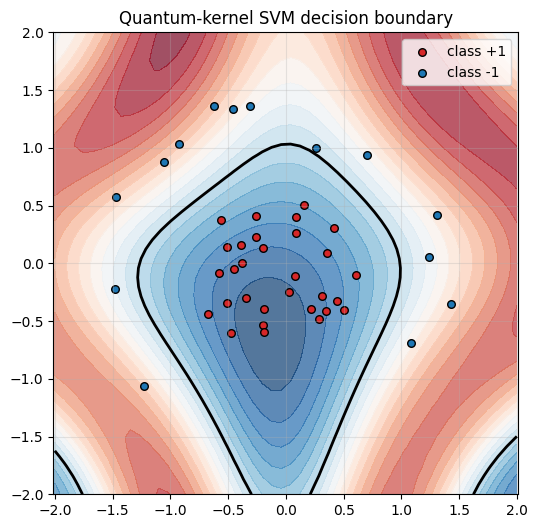

In [4]:
# Visualize the quantum-kernel SVM decision boundary
gx = np.linspace(-2, 2, 50); gy = np.linspace(-2, 2, 50)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX.ravel(), GY.ravel()], 1)
K_grid = gram_matrix(grid, Xtr, quantum_kernel_scratch)
Zg = (K_grid @ (alpha*ytr) + bias).reshape(GX.shape)

plt.figure(figsize=(6, 6))
plt.contourf(GX, GY, Zg, levels=20, cmap="RdBu", alpha=0.7)
plt.contour(GX, GY, Zg, levels=[0], colors="k", linewidths=2)
plt.scatter(Xtr[ytr==1,0], Xtr[ytr==1,1], c="C3", s=30, edgecolors="k", label="class +1")
plt.scatter(Xtr[ytr==-1,0], Xtr[ytr==-1,1], c="C0", s=30, edgecolors="k", label="class -1")
plt.title("Quantum-kernel SVM decision boundary"); plt.legend(); plt.axis("equal"); plt.show()


The quantum-kernel SVM separates the nonlinear two-class problem with a curved boundary, using a
*convex* classical optimizer fed by quantum-computed similarities — no barren plateaus, no fragile
circuit training. This division of labor (quantum embedding + classical convex optimization) is one of
the most practically promising templates in near-term quantum machine learning.

## 4. Capstone: quantum versus classical

We close the course with an honest comparison. On the same dataset we evaluate three models:

1. the **quantum-kernel SVM** above,
2. a **classical RBF-kernel SVM** (the standard nonlinear baseline), and
3. a **linear classifier** (to show the task is genuinely nonlinear).

The goal is not to declare a winner — for a small 2-D dataset, classical methods are excellent and a
quantum computer is unnecessary — but to understand the *landscape*: quantum kernels are a real,
working method whose advantage, if any, appears only for data whose structure matches a quantum feature
map that is hard to simulate classically. Building that intuition is the right place to end.


Test accuracy comparison on the circles dataset:
  Quantum kernel  : 0.812
  Classical RBF   : 0.938
  Linear          : 0.438


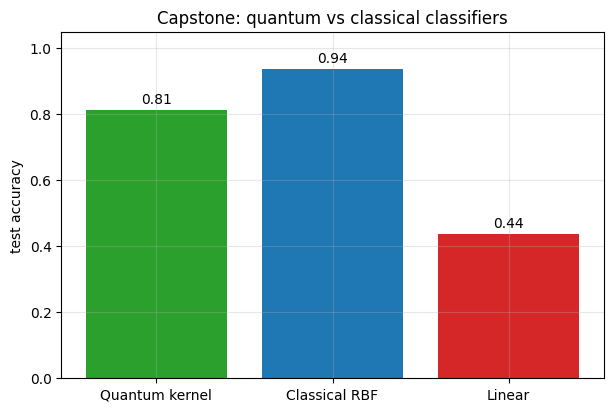

In [5]:
# Classical RBF kernel and a linear kernel for comparison
def rbf_kernel(x1, x2, gamma=1.0):
    return np.exp(-gamma*np.sum((x1-x2)**2))
def linear_kernel(x1, x2):
    return np.dot(x1, x2)

results = {}
for name, kfun in [("Quantum kernel", quantum_kernel_scratch),
                   ("Classical RBF", rbf_kernel),
                   ("Linear", linear_kernel)]:
    Ktr = gram_matrix(Xtr, Xtr, kfun)
    al, bi = train_svm_dual(Ktr, ytr, C=1.0)
    Kte = gram_matrix(Xte, Xtr, kfun)
    acc = np.mean(svm_predict(Kte, al, ytr, bi) == yte)
    results[name] = acc

print("Test accuracy comparison on the circles dataset:")
for k, v in results.items():
    print(f"  {k:16s}: {v:.3f}")

plt.figure()
plt.bar(results.keys(), results.values(), color=["C2","C0","C3"])
plt.ylabel("test accuracy"); plt.ylim(0, 1.05)
plt.title("Capstone: quantum vs classical classifiers")
for i,(k,v) in enumerate(results.items()):
    plt.text(i, v+0.02, f"{v:.2f}", ha="center")
plt.show()


The quantum and classical RBF kernels both solve the nonlinear problem well, while the linear model
lags — confirming the task needs a nonlinear feature space and that the quantum kernel provides a valid
one. On this small classical dataset there is no quantum advantage, and that is the honest state of the
field today: quantum machine learning offers genuinely new model classes, but a demonstrated, practical
advantage awaits both better hardware and problems whose structure is natively quantum (e.g. data from
quantum systems themselves).

## 5. Summary and course conclusion

- **Kernel methods** classify via inner products in a feature space; the **quantum kernel** uses the
  fidelity $|\langle\phi(x')|\phi(x)\rangle|^2$ between data-encoded quantum states, computed by an
  overlap circuit.
- A **quantum-kernel SVM** pairs quantum-computed similarities with a **convex** classical optimizer,
  sidestepping the barren-plateau and local-minima problems of variational training.
- The **capstone** compared quantum and classical models fairly: quantum kernels are a real, working
  method, but their advantage is problem-dependent and not yet demonstrated on small classical data.

**The arc of the course.** We began with a single qubit as a complex vector and built a state-vector
simulator (Week 1), added entanglement, measurement, and the CHSH violation (Week 2), and implemented
the algorithmic canon — Deutsch–Jozsa, Grover, the QFT (Week 3). We then entered the variational era:
parameter-shift gradients and VQE with the PennyLane bridge (Week 4), variational quantum classifiers
and barren plateaus (Week 5), and quantum kernels with an honest quantum-vs-classical capstone
(Week 6). The throughline is that quantum machine learning is, at heart, **linear algebra plus
optimization on an exponentially large space** — the same tools as classical ML, reorganized around
superposition, entanglement, and interference. You now have the foundation to read the research
literature and build on it.


## 6. Exercises

**Exercise 1 (kernel geometry).** Compute and visualize the full training Gram matrix for the quantum
and RBF kernels side by side. How do their similarity structures differ on the circles data?

**Exercise 2 (feature-map design).** Replace the feature map with the entangling **ZZ feature map**
(Havlíček et al.) and measure its effect on quantum-kernel SVM accuracy. Does more entanglement help
here?

**Exercise 3 (kernel-target alignment).** Implement kernel-target alignment, a measure of how well a
kernel matches the labels, and use it to compare quantum feature maps without training a full SVM.

**Exercise 4 (quantum-native data).** Generate a dataset by sampling measurement outcomes from a family
of quantum circuits (so the data is intrinsically quantum), and compare quantum-kernel versus RBF-kernel
accuracy. This is the regime where a quantum advantage is most plausible — investigate whether you can
observe one.


In [6]:
# Scratch space for the exercises.
